<a href="https://colab.research.google.com/github/AndreiAf02/Fourier_Stock_Prediction/blob/main/GSPTSE_Performance_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import math
import seaborn as sns
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
stock_symbol = '^GSPTSE'
start_date = '2024-01-01'
end_date = '2026-01-15'
interval_val='1d'

stock = yf.Ticker(stock_symbol)
hist = stock.history(start=start_date, end=end_date, interval=interval_val)

colors_vol = np.where(hist['Close']>=hist['Open'], 'green', 'red')

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, subplot_titles=(str(stock_symbol),
                                                                       'Volume'),
                          row_width=[0.3, 0.7], vertical_spacing=0.05)
fig.update_layout(autosize=False, width=1600, height=1000)


fig = fig.add_trace(go.Candlestick(x=hist.index, open=hist['Open'],
                                  high = hist['High'], low = hist['Low'],
                                  close = hist['Close'], name='Price'), row=1, col=1)

fig = fig.add_trace(go.Bar(x=hist.index, y=hist['Volume'], name='Volume', marker_color=colors_vol), row=2, col=1)


fig.update_xaxes(rangeslider_visible=False, row=1, col=1)
fig.update_xaxes(rangeslider_visible=True, row=2, col=1)

fig.show()

## DNN:

In [23]:
path_to_data = 'https://raw.githubusercontent.com/AndreiAf02/Fourier_Stock_Prediction/refs/heads/main/GSPTSE/DNN_5D/'

In [24]:
short_data = pd.read_csv(path_to_data+'Short_DNN_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_data = pd.read_csv(path_to_data+'Long_DNN_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_fwr_data = pd.read_csv(path_to_data+'Short_FWR_DNN_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_fwr_data = pd.read_csv(path_to_data+'Long_FWR_DNN_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_lin_data = pd.read_csv(path_to_data+'Short_LinDrift_DNN_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_lin_data = pd.read_csv(path_to_data+'Long_LinDrift_DNN_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_fej_data = pd.read_csv(path_to_data+'Short_Fejer_DNN_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_fej_data = pd.read_csv(path_to_data+'Long_Fejer_DNN_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_lan_data = pd.read_csv(path_to_data+'Short_Lanczos_DNN_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_lan_data = pd.read_csv(path_to_data+'Long_Lanczos_DNN_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_stat_data = pd.read_csv(path_to_data+'Short_Stationary_DNN_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_stat_data = pd.read_csv(path_to_data+'Long_Stationary_DNN_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_pad_data = pd.read_csv(path_to_data+'Short_Padding_DNN_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_pad_data = pd.read_csv(path_to_data+'Long_Padding_DNN_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_fwr_data

,Unnamed: 0,Open,High,Low,Close,Volume
0,0,0.527812,0.469360,0.459350,0.534754,0.156496
1,1,0.337228,0.361727,0.246720,0.260764,0.157261
2,2,0.258626,0.307683,0.273308,0.257951,0.160080
3,3,0.219987,0.306121,0.247483,0.370734,0.157222
4,4,0.175476,0.151766,0.195024,0.205179,0.177792
...,...,...,...,...,...,...
95,95,0.188902,0.163740,0.158485,0.227226,0.164547
96,96,0.312195,0.361647,0.304157,0.289767,0.154617
97,97,0.170623,0.296305,0.353316,0.173477,0.154151
98,98,0.270186,0.404027,0.223939,0.298642,0.158624



------------------------- Open -------------------------
Simple & 0.2822 & 0.9754 \\
Padding & 0.2723 & 1.0621 \\
FWR & 0.2877 & 1.1388 \\
Fejer & 0.2655 & 0.9622 \\
Lanczos & 0.2859 & 0.9191 \\
Stationary & 0.249 & 0.8179 \\

Smallest median NRMSE (Short): Stationary
Smallest median NRMSE (Long): Stationary


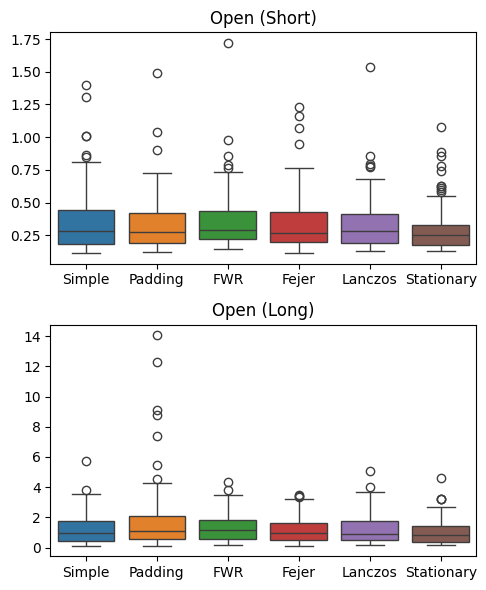


------------------------- High -------------------------
Simple & 0.2292 & 0.9449 \\
Padding & 0.2784 & 0.9616 \\
FWR & 0.3059 & 1.1712 \\
Fejer & 0.2679 & 0.9769 \\
Lanczos & 0.2742 & 0.9236 \\
Stationary & 0.2663 & 0.8552 \\

Smallest median NRMSE (Short): Stationary
Smallest median NRMSE (Long): Stationary


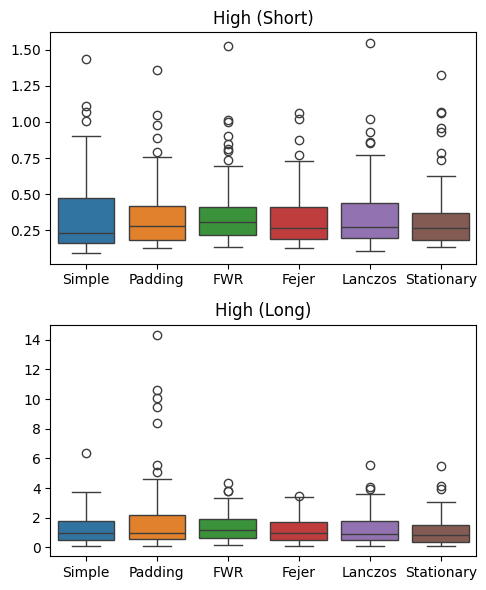


------------------------- Low -------------------------
Simple & 0.2915 & 0.989 \\
Padding & 0.2647 & 0.9202 \\
FWR & 0.2784 & 1.0965 \\
Fejer & 0.2568 & 0.9934 \\
Lanczos & 0.2731 & 0.9014 \\
Stationary & 0.2844 & 0.8269 \\

Smallest median NRMSE (Short): Fejer
Smallest median NRMSE (Long): Stationary


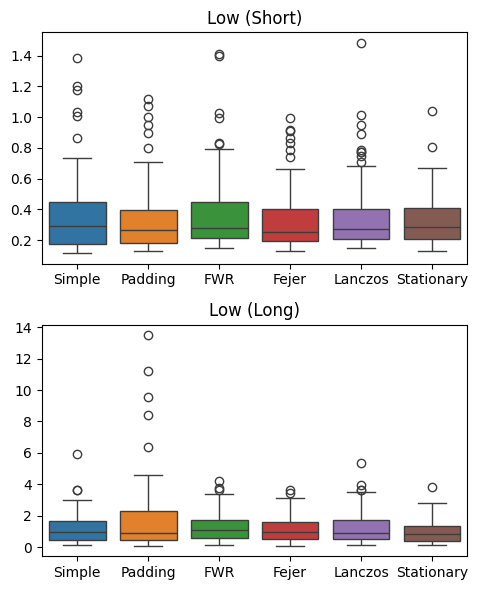


------------------------- Close -------------------------
Simple & 0.2587 & 0.9201 \\
Padding & 0.2693 & 0.9863 \\
FWR & 0.262 & 1.0747 \\
Fejer & 0.2847 & 1.0552 \\
Lanczos & 0.2812 & 0.9359 \\
Stationary & 0.256 & 0.8354 \\

Smallest median NRMSE (Short): Stationary
Smallest median NRMSE (Long): Stationary


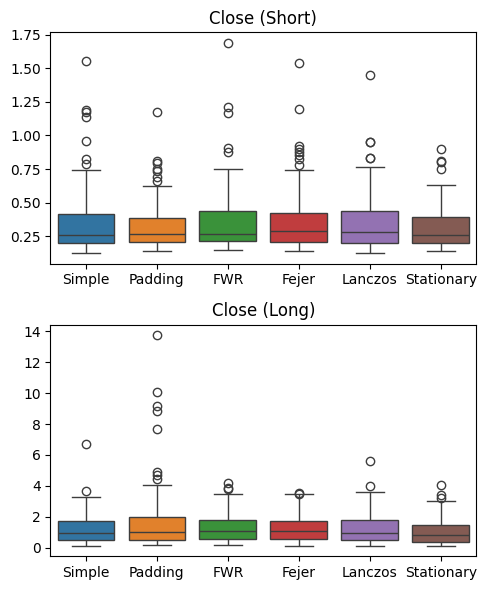


------------------------- Volume -------------------------
Simple & 0.1667 & 0.1669 \\
Padding & 0.1642 & 0.1671 \\
FWR & 0.1602 & 0.1616 \\
Fejer & 0.1614 & 0.1617 \\
Lanczos & 0.163 & 0.1668 \\
Stationary & 0.1628 & 0.1632 \\

Smallest median NRMSE (Short): FWR
Smallest median NRMSE (Long): FWR


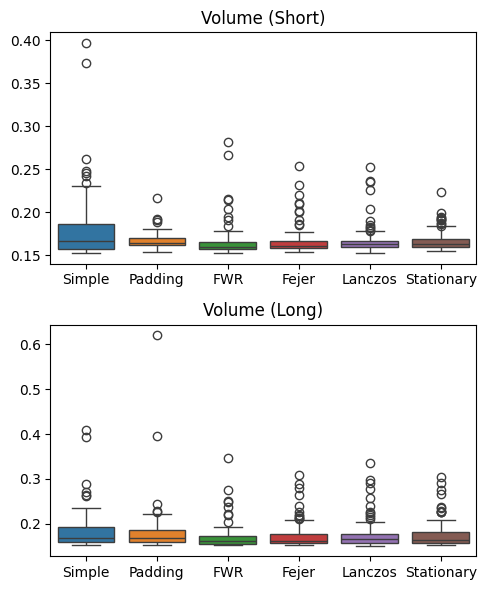

In [26]:
col_list = ['Open', 'High', 'Low', 'Close', 'Volume']

method_list = ['Simple', 'Padding', 'FWR', 'Fejer', 'Lanczos', 'Stationary']


for col in col_list:
  perf_df = pd.DataFrame()
  data_simple = short_data[col]
  data_fwr = short_fwr_data[col]
  data_lin = short_lin_data[col]
  data_fej = short_fej_data[col]
  data_lan = short_lan_data[col]
  data_stat = short_stat_data[col]
  data_pad = short_pad_data[col]

  perf_df['Simple'] = data_simple
  perf_df['Padding'] = data_pad
  perf_df['FWR'] = data_fwr
  perf_df['Fejer'] = data_fej
  perf_df['Lanczos'] = data_lan
  # perf_df['Linear'] = data_lin
  perf_df['Stationary'] = data_stat

  ## Long-term Prediction Performance:
  perf_long_df = pd.DataFrame()
  data_simple_long = long_data[col]
  data_fwr_long = long_fwr_data[col]
  data_lin_long = long_lin_data[col]
  data_fej_long = long_fej_data[col]
  data_lan_long = long_lan_data[col]
  data_stat_long = long_stat_data[col]
  data_pad_long = long_pad_data[col]

  perf_long_df['Simple'] = data_simple_long
  perf_long_df['Padding'] = data_pad_long
  perf_long_df['FWR'] = data_fwr_long
  perf_long_df['Fejer'] = data_fej_long
  perf_long_df['Lanczos'] = data_lan_long
  # perf_long_df['Linear'] = data_lin_long
  perf_long_df['Stationary'] = data_stat_long


  print('')
  print('-'*25, col, '-'*25)
  # print(perf_df.median())

  for method in method_list:
    print(f'{method} & {round(perf_df[method].median(),4)} & {round(perf_long_df[method].median(),4)} \\\\')
  print('')
  print('Smallest median NRMSE (Short):', perf_df[['Padding', 'FWR', 'Fejer', 'Lanczos', 'Stationary']].median().idxmin())
  print('Smallest median NRMSE (Long):', perf_long_df[['Padding', 'FWR', 'Fejer', 'Lanczos', 'Stationary']].median().idxmin())

  fig, axes = plt.subplots(2, 1, figsize=(5, 6), sharex = False) #plt.plot(figsize=(16,12))
  # plt.subplot(2, 1, 1)
  axes[0].set_title(f'{col} (Short)')
  sns.boxplot(perf_df, ax = axes[0])

  # plt.subplot(2, 1, 2)
  axes[1].set_title(f'{col} (Long)')
  sns.boxplot(perf_long_df, ax = axes[1])
  # sns.boxplot(perf_long_df)
  plt.tight_layout()
  plt.show()

In [16]:
# col_list = ['Open', 'High', 'Low', 'Close', 'Volume']


# for col in col_list:
#   perf_df = pd.DataFrame()
#   data_simple = long_data[col]
#   data_fwr = long_fwr_data[col]
#   data_lin = long_lin_data[col]
#   data_fej = long_fej_data[col]
#   data_lan = long_lan_data[col]
#   data_stat = long_stat_data[col]
#   data_pad = long_pad_data[col]

#   perf_df['Simple'] = data_simple
#   perf_df['Padding'] = data_pad
#   perf_df['FWR'] = data_fwr
#   perf_df['Fejer'] = data_fej
#   perf_df['Lanczos'] = data_lan
#   # perf_df['Linear'] = data_lin
#   perf_df['Stationary'] = data_stat

#   print('')
#   print('-'*25, col, ' (Long-Term)', '-'*25)
#   print(perf_df.median())
#   print('Smallest median NRMSE:', perf_df[['Padding', 'FWR', 'Fejer', 'Lanczos', 'Stationary']].median().idxmin())

#   plt.plot()
#   plt.title(col + ' (Long-Term)')
#   sns.boxplot(perf_df)
#   plt.show()

##LSTM:

In [27]:
path_to_data = 'https://raw.githubusercontent.com/AndreiAf02/Fourier_Stock_Prediction/refs/heads/main/GSPTSE/LSTM/'

In [28]:
short_data = pd.read_csv(path_to_data+'Short_LSTM_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_data = pd.read_csv(path_to_data+'Long_LSTM_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_fwr_data = pd.read_csv(path_to_data+'Short_FWR_LSTM_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_fwr_data = pd.read_csv(path_to_data+'Long_FWR_LSTM_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_lin_data = pd.read_csv(path_to_data+'Short_LinDrift_LSTM_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_lin_data = pd.read_csv(path_to_data+'Long_LinDrift_LSTM_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_fej_data = pd.read_csv(path_to_data+'Short_Fejer_LSTM_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_fej_data = pd.read_csv(path_to_data+'Long_Fejer_LSTM_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_lan_data = pd.read_csv(path_to_data+'Short_Lanczos_LSTM_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_lan_data = pd.read_csv(path_to_data+'Long_Lanczos_LSTM_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_stat_data = pd.read_csv(path_to_data+'Short_Stationary_LSTM_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_stat_data = pd.read_csv(path_to_data+'Long_Stationary_LSTM_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_pad_data = pd.read_csv(path_to_data+'Short_Padding_LSTM_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_pad_data = pd.read_csv(path_to_data+'Long_Padding_LSTM_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_fwr_data

,Unnamed: 0,Open,High,Low,Close,Volume
0,0,0.434621,0.745429,0.651594,0.518422,0.169711
1,1,0.282580,0.318253,0.247957,0.196335,0.163733
2,2,0.337145,0.329859,0.192334,0.384820,0.159122
3,3,0.439320,0.381287,0.410550,0.329202,0.157930
4,4,0.127867,0.165755,0.200243,0.156103,0.166048
...,...,...,...,...,...,...
95,95,0.154977,0.170565,0.392481,0.217529,0.168542
96,96,0.515087,0.545977,0.450505,0.491736,0.155427
97,97,0.456725,0.497215,0.490405,0.527225,0.155261
98,98,0.295378,0.192515,0.194584,0.212000,0.158929



------------------------- Open -------------------------
Simple & 0.3678 & 0.9767 \\
Padding & 0.29 & 0.8852 \\
FWR & 0.3472 & 0.8543 \\
Fejer & 0.3164 & 0.8452 \\
Lanczos & 0.3066 & 0.8365 \\
Stationary & 0.2854 & 0.7617 \\

Smallest median NRMSE (Short): Stationary
Smallest median NRMSE (Long): Stationary


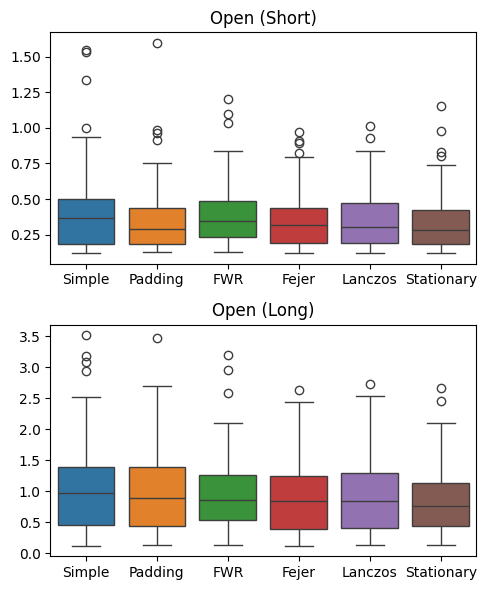


------------------------- High -------------------------
Simple & 0.3624 & 1.0323 \\
Padding & 0.3075 & 0.8524 \\
FWR & 0.3295 & 0.8548 \\
Fejer & 0.3558 & 0.9301 \\
Lanczos & 0.3231 & 0.9036 \\
Stationary & 0.3354 & 0.8211 \\

Smallest median NRMSE (Short): Padding
Smallest median NRMSE (Long): Stationary


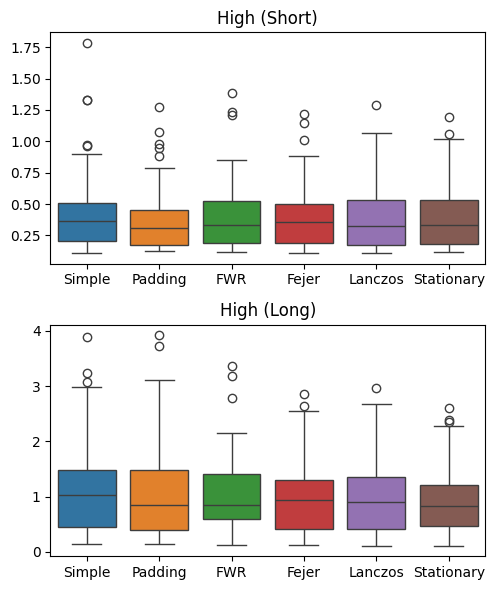


------------------------- Low -------------------------
Simple & 0.3401 & 0.9721 \\
Padding & 0.2768 & 0.8202 \\
FWR & 0.3236 & 0.8005 \\
Fejer & 0.2838 & 0.7614 \\
Lanczos & 0.2997 & 0.7917 \\
Stationary & 0.3221 & 0.7404 \\

Smallest median NRMSE (Short): Padding
Smallest median NRMSE (Long): Stationary


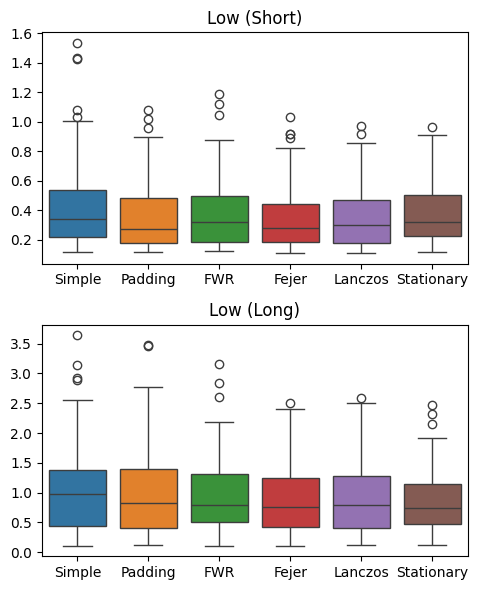


------------------------- Close -------------------------
Simple & 0.3247 & 0.9352 \\
Padding & 0.3012 & 0.8998 \\
FWR & 0.3099 & 0.7814 \\
Fejer & 0.3296 & 0.8356 \\
Lanczos & 0.3183 & 0.8318 \\
Stationary & 0.2992 & 0.7815 \\

Smallest median NRMSE (Short): Stationary
Smallest median NRMSE (Long): FWR


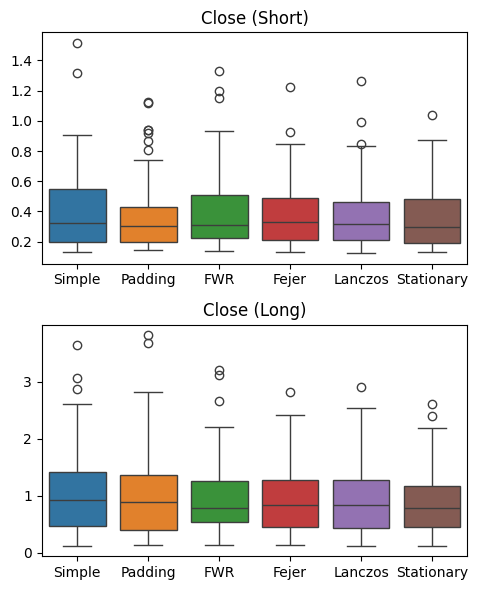


------------------------- Volume -------------------------
Simple & 0.165 & 0.1637 \\
Padding & 0.1604 & 0.1601 \\
FWR & 0.1595 & 0.1592 \\
Fejer & 0.1595 & 0.1595 \\
Lanczos & 0.1596 & 0.1594 \\
Stationary & 0.1621 & 0.163 \\

Smallest median NRMSE (Short): Fejer
Smallest median NRMSE (Long): FWR


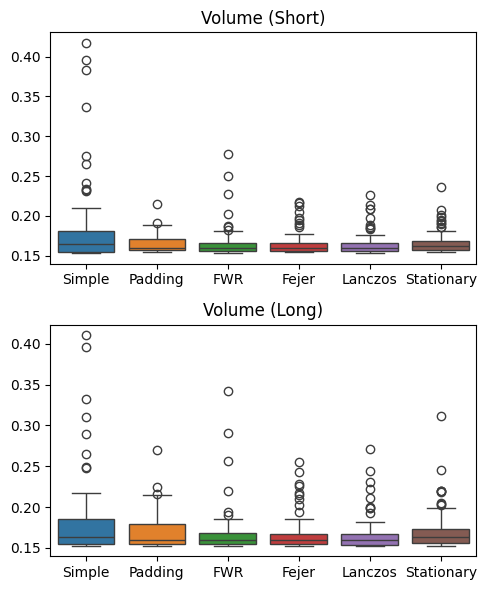

In [29]:
col_list = ['Open', 'High', 'Low', 'Close', 'Volume']


for col in col_list:
  perf_df = pd.DataFrame()
  data_simple = short_data[col]
  data_fwr = short_fwr_data[col]
  data_lin = short_lin_data[col]
  data_fej = short_fej_data[col]
  data_lan = short_lan_data[col]
  data_stat = short_stat_data[col]
  data_pad = short_pad_data[col]

  perf_df['Simple'] = data_simple
  perf_df['Padding'] = data_pad
  perf_df['FWR'] = data_fwr
  perf_df['Fejer'] = data_fej
  perf_df['Lanczos'] = data_lan
  # perf_df['Linear'] = data_lin
  perf_df['Stationary'] = data_stat

  ## Long-term Prediction Performance:
  perf_long_df = pd.DataFrame()
  data_simple_long = long_data[col]
  data_fwr_long = long_fwr_data[col]
  data_lin_long = long_lin_data[col]
  data_fej_long = long_fej_data[col]
  data_lan_long = long_lan_data[col]
  data_stat_long = long_stat_data[col]
  data_pad_long = long_pad_data[col]

  perf_long_df['Simple'] = data_simple_long
  perf_long_df['Padding'] = data_pad_long
  perf_long_df['FWR'] = data_fwr_long
  perf_long_df['Fejer'] = data_fej_long
  perf_long_df['Lanczos'] = data_lan_long
  # perf_long_df['Linear'] = data_lin_long
  perf_long_df['Stationary'] = data_stat_long


  print('')
  print('-'*25, col, '-'*25)
  # print(perf_df.median())

  for method in method_list:
    print(f'{method} & {round(perf_df[method].median(),4)} & {round(perf_long_df[method].median(),4)} \\\\')
  print('')
  print('Smallest median NRMSE (Short):', perf_df[['Padding', 'FWR', 'Fejer', 'Lanczos', 'Stationary']].median().idxmin())
  print('Smallest median NRMSE (Long):', perf_long_df[['Padding', 'FWR', 'Fejer', 'Lanczos', 'Stationary']].median().idxmin())

  fig, axes = plt.subplots(2, 1, figsize=(5, 6), sharex = False)
  axes[0].set_title(f'{col} (Short)')
  sns.boxplot(perf_df, ax = axes[0])

  axes[1].set_title(f'{col} (Long)')
  sns.boxplot(perf_long_df, ax = axes[1])
  plt.tight_layout()
  plt.show()

## GRU:

In [31]:
path_to_data = 'https://raw.githubusercontent.com/AndreiAf02/Fourier_Stock_Prediction/refs/heads/main/GSPTSE/GRU/'

In [32]:
short_data = pd.read_csv(path_to_data+'Short_GRU_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_data = pd.read_csv(path_to_data+'Long_GRU_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_fwr_data = pd.read_csv(path_to_data+'Short_FWR_GRU_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_fwr_data = pd.read_csv(path_to_data+'Long_FWR_GRU_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_lin_data = pd.read_csv(path_to_data+'Short_LinDrift_GRU_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_lin_data = pd.read_csv(path_to_data+'Long_LinDrift_GRU_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_fej_data = pd.read_csv(path_to_data+'Short_Fejer_GRU_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_fej_data = pd.read_csv(path_to_data+'Long_Fejer_GRU_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_lan_data = pd.read_csv(path_to_data+'Short_Lanczos_GRU_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_lan_data = pd.read_csv(path_to_data+'Long_Lanczos_GRU_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_stat_data = pd.read_csv(path_to_data+'Short_Stationary_GRU_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_stat_data = pd.read_csv(path_to_data+'Long_Stationary_GRU_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_pad_data = pd.read_csv(path_to_data+'Short_Padding_GRU_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_pad_data = pd.read_csv(path_to_data+'Long_Padding_GRU_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_fwr_data

,Unnamed: 0,Open,High,Low,Close,Volume
0,0,0.116806,0.165416,0.108386,0.144044,0.176089
1,1,0.189915,0.261861,0.264506,0.265546,0.166025
2,2,0.169562,0.131439,0.115033,0.135560,0.161707
3,3,0.147488,0.115613,0.128621,0.127728,0.156694
4,4,0.228164,0.146011,0.219000,0.203807,0.162328
...,...,...,...,...,...,...
95,95,0.133505,0.145381,0.154512,0.170041,0.163926
96,96,0.334447,0.152603,0.334350,0.121062,0.157665
97,97,0.114474,0.124222,0.133056,0.202279,0.163722
98,98,0.113398,0.105070,0.104064,0.128074,0.157591



------------------------- Open -------------------------
Simple & 0.2346 & 1.1618 \\
Padding & 0.2226 & 1.0186 \\
FWR & 0.1913 & 0.9214 \\
Fejer & 0.2025 & 1.0958 \\
Lanczos & 0.1958 & 0.9449 \\
Stationary & 0.1878 & 0.8934 \\

Smallest median NRMSE (Short): Stationary
Smallest median NRMSE (Long): Stationary


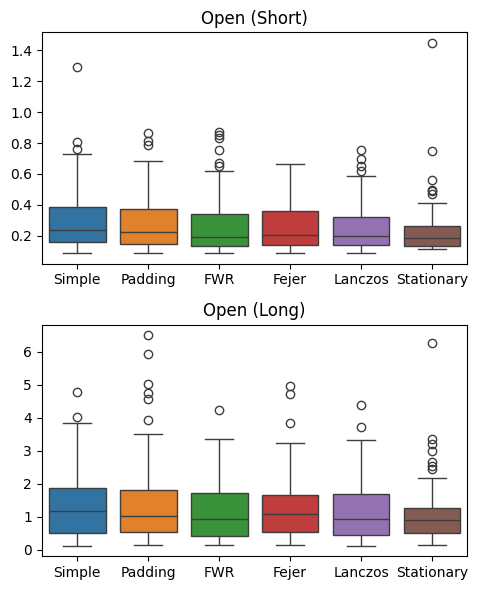


------------------------- High -------------------------
Simple & 0.2058 & 1.1342 \\
Padding & 0.2567 & 1.2389 \\
FWR & 0.2021 & 0.918 \\
Fejer & 0.2392 & 1.1074 \\
Lanczos & 0.209 & 1.0292 \\
Stationary & 0.2111 & 0.9744 \\

Smallest median NRMSE (Short): FWR
Smallest median NRMSE (Long): FWR


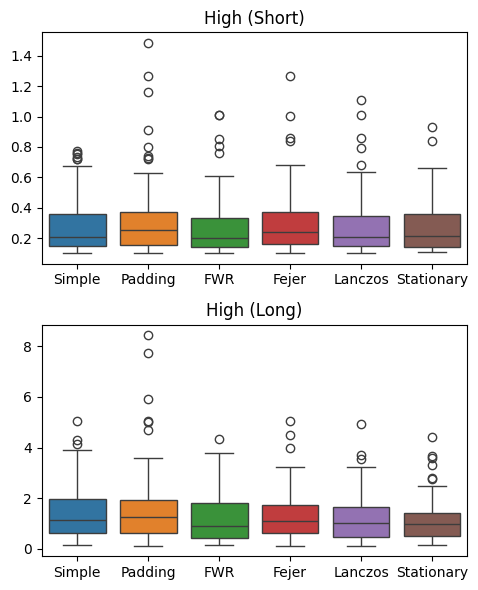


------------------------- Low -------------------------
Simple & 0.2608 & 1.1074 \\
Padding & 0.2215 & 1.081 \\
FWR & 0.2051 & 0.8375 \\
Fejer & 0.214 & 1.0062 \\
Lanczos & 0.2024 & 0.9645 \\
Stationary & 0.2247 & 0.8632 \\

Smallest median NRMSE (Short): Lanczos
Smallest median NRMSE (Long): FWR


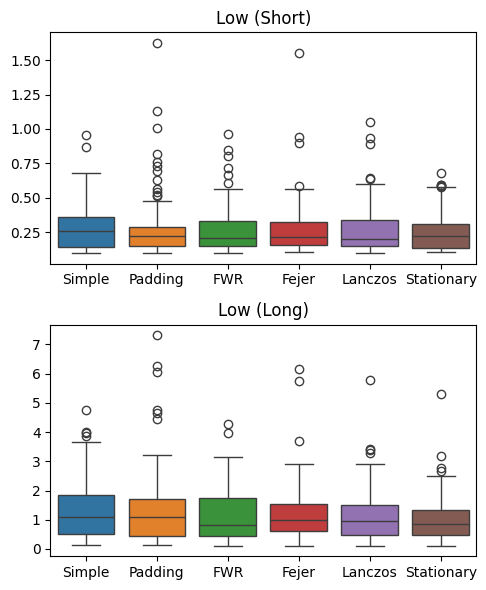


------------------------- Close -------------------------
Simple & 0.2464 & 1.1053 \\
Padding & 0.2323 & 1.1511 \\
FWR & 0.2199 & 0.9485 \\
Fejer & 0.2298 & 1.0985 \\
Lanczos & 0.226 & 1.0282 \\
Stationary & 0.2124 & 0.8947 \\

Smallest median NRMSE (Short): Stationary
Smallest median NRMSE (Long): Stationary


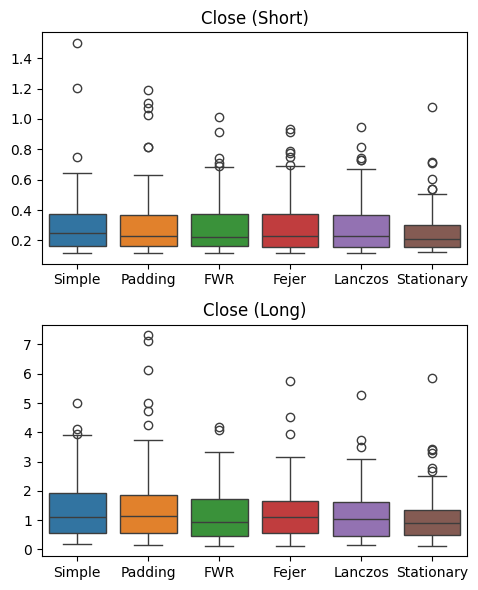


------------------------- Volume -------------------------
Simple & 0.1662 & 0.1715 \\
Padding & 0.1683 & 0.1712 \\
FWR & 0.1632 & 0.164 \\
Fejer & 0.1645 & 0.1631 \\
Lanczos & 0.1639 & 0.1612 \\
Stationary & 0.1668 & 0.1699 \\

Smallest median NRMSE (Short): FWR
Smallest median NRMSE (Long): Lanczos


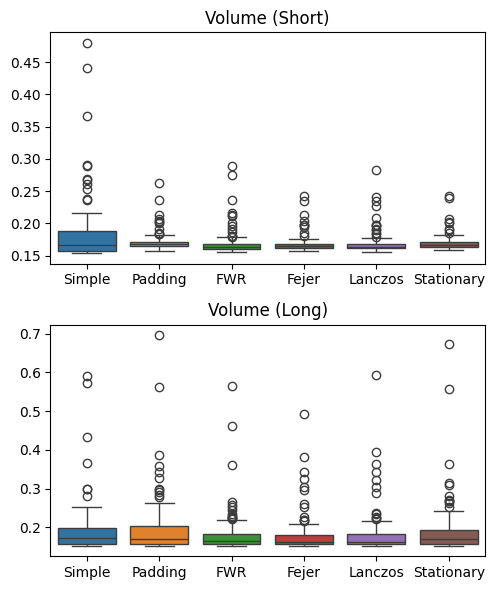

In [33]:
col_list = ['Open', 'High', 'Low', 'Close', 'Volume']


for col in col_list:
  perf_df = pd.DataFrame()
  data_simple = short_data[col]
  data_fwr = short_fwr_data[col]
  data_lin = short_lin_data[col]
  data_fej = short_fej_data[col]
  data_lan = short_lan_data[col]
  data_stat = short_stat_data[col]
  data_pad = short_pad_data[col]

  perf_df['Simple'] = data_simple
  perf_df['Padding'] = data_pad
  perf_df['FWR'] = data_fwr
  perf_df['Fejer'] = data_fej
  perf_df['Lanczos'] = data_lan
  # perf_df['Linear'] = data_lin
  perf_df['Stationary'] = data_stat

  ## Long-term Prediction Performance:
  perf_long_df = pd.DataFrame()
  data_simple_long = long_data[col]
  data_fwr_long = long_fwr_data[col]
  data_lin_long = long_lin_data[col]
  data_fej_long = long_fej_data[col]
  data_lan_long = long_lan_data[col]
  data_stat_long = long_stat_data[col]
  data_pad_long = long_pad_data[col]

  perf_long_df['Simple'] = data_simple_long
  perf_long_df['Padding'] = data_pad_long
  perf_long_df['FWR'] = data_fwr_long
  perf_long_df['Fejer'] = data_fej_long
  perf_long_df['Lanczos'] = data_lan_long
  # perf_long_df['Linear'] = data_lin_long
  perf_long_df['Stationary'] = data_stat_long


  print('')
  print('-'*25, col, '-'*25)
  # print(perf_df.median())

  for method in method_list:
    print(f'{method} & {round(perf_df[method].median(),4)} & {round(perf_long_df[method].median(),4)} \\\\')
  print('')
  print('Smallest median NRMSE (Short):', perf_df[['Padding', 'FWR', 'Fejer', 'Lanczos', 'Stationary']].median().idxmin())
  print('Smallest median NRMSE (Long):', perf_long_df[['Padding', 'FWR', 'Fejer', 'Lanczos', 'Stationary']].median().idxmin())

  fig, axes = plt.subplots(2, 1, figsize=(5, 6), sharex = False)
  axes[0].set_title(f'{col} (Short)')
  sns.boxplot(perf_df, ax = axes[0])

  axes[1].set_title(f'{col} (Long)')
  sns.boxplot(perf_long_df, ax = axes[1])
  plt.tight_layout()
  plt.show()

## Transformer:

In [34]:
path_to_data = 'https://raw.githubusercontent.com/AndreiAf02/Fourier_Stock_Prediction/refs/heads/main/GSPTSE/Transformer/'

In [35]:
short_data = pd.read_csv(path_to_data+'Short_Transformer_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_data = pd.read_csv(path_to_data+'Long_Transformer_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_fwr_data = pd.read_csv(path_to_data+'Short_Transformer_FWR_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_fwr_data = pd.read_csv(path_to_data+'Long_Transformer_FWR_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_lin_data = pd.read_csv(path_to_data+'Short_Transformer_LinDrift_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_lin_data = pd.read_csv(path_to_data+'Long_Transformer_LinDrift_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_fej_data = pd.read_csv(path_to_data+'Short_Transformer_Fejer_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_fej_data = pd.read_csv(path_to_data+'Long_Transformer_Fejer_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_lan_data = pd.read_csv(path_to_data+'Short_Transformer_Lanczos_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_lan_data = pd.read_csv(path_to_data+'Long_Transformer_Lanczos_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_stat_data = pd.read_csv(path_to_data+'Short_Transformer_Stationary_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_stat_data = pd.read_csv(path_to_data+'Long_Transformer_Stationary_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_stat_smoothed_data = pd.read_csv(path_to_data+'Short_Transformer_Stationary_Smoothed_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_stat_smoothed_data = pd.read_csv(path_to_data+'Long_Transformer_Stationary_Smoothed_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_pad_data = pd.read_csv(path_to_data+'Short_Transformer_Padding_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)
long_pad_data = pd.read_csv(path_to_data+'Long_Transformer_Padding_Fine_Tuning_NRMSE_^GSPTSE.csv', sep=",", header=0)

short_fwr_data

,Unnamed: 0,Base Seed,Fine-Tune Seed,Open,High,Low,Close,Volume
0,0,1.0,1.0,0.143375,0.139751,0.133935,0.134640,0.150241
1,1,1.0,2.0,0.148664,0.134088,0.113846,0.147297,0.152205
2,2,1.0,3.0,0.148826,0.139847,0.125720,0.136979,0.151946
3,3,1.0,4.0,0.195870,0.186468,0.150824,0.184669,0.151719
4,4,1.0,5.0,0.146579,0.131881,0.113485,0.146240,0.151951
...,...,...,...,...,...,...,...,...
95,95,5.0,16.0,0.170210,0.166751,0.153253,0.158730,0.153435
96,96,5.0,17.0,0.175660,0.182482,0.170983,0.166215,0.153733
97,97,5.0,18.0,0.181659,0.191543,0.177100,0.170971,0.153834
98,98,5.0,19.0,0.166857,0.150744,0.127896,0.173410,0.152773



------------------------- Open -------------------------
Simple & 0.1552 & 0.5296 \\
Padding & 0.1828 & 0.564 \\
FWR & 0.1645 & 0.4951 \\
Fejer & 0.1459 & 0.5385 \\
Lanczos & 0.1491 & 0.5387 \\
Stationary & 0.1722 & 0.8076 \\

Smallest median NRMSE (Short): Fejer
Smallest median NRMSE (Long): FWR


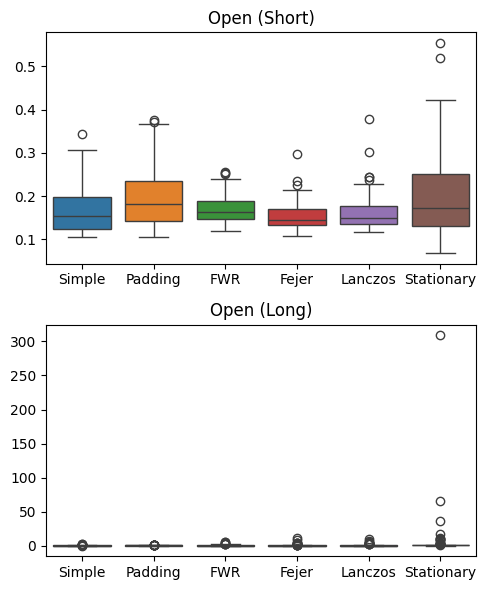


------------------------- High -------------------------
Simple & 0.1742 & 0.5528 \\
Padding & 0.2012 & 0.5798 \\
FWR & 0.1583 & 0.5031 \\
Fejer & 0.1352 & 0.5599 \\
Lanczos & 0.14 & 0.6022 \\
Stationary & 0.1991 & 0.8439 \\

Smallest median NRMSE (Short): Fejer
Smallest median NRMSE (Long): FWR


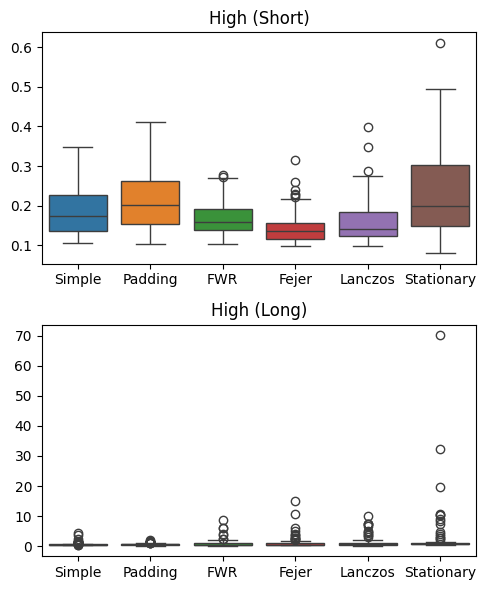


------------------------- Low -------------------------
Simple & 0.1596 & 0.513 \\
Padding & 0.1928 & 0.5425 \\
FWR & 0.1436 & 0.4668 \\
Fejer & 0.1201 & 0.4729 \\
Lanczos & 0.1262 & 0.5071 \\
Stationary & 0.1803 & 0.7384 \\

Smallest median NRMSE (Short): Fejer
Smallest median NRMSE (Long): FWR


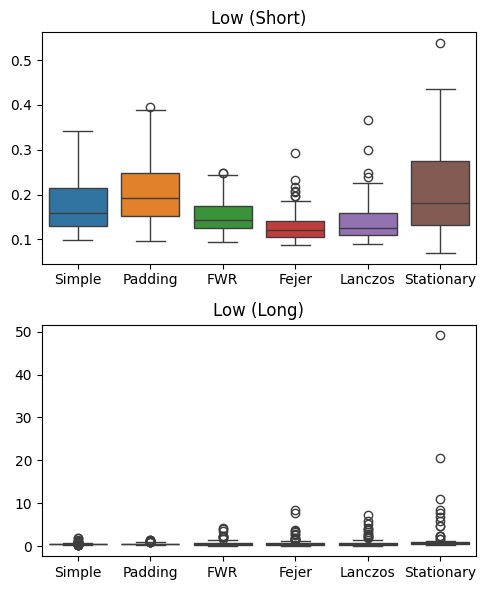


------------------------- Close -------------------------
Simple & 0.1654 & 0.4982 \\
Padding & 0.1918 & 0.5288 \\
FWR & 0.1541 & 0.4576 \\
Fejer & 0.145 & 0.5283 \\
Lanczos & 0.1493 & 0.5649 \\
Stationary & 0.1967 & 0.8285 \\

Smallest median NRMSE (Short): Fejer
Smallest median NRMSE (Long): FWR


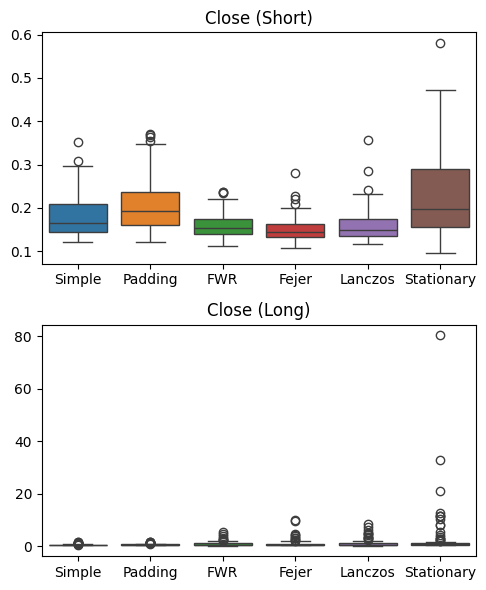


------------------------- Volume -------------------------
Simple & 0.1544 & 0.1543 \\
Padding & 0.1542 & 0.1544 \\
FWR & 0.1528 & 0.153 \\
Fejer & 0.1623 & 0.1537 \\
Lanczos & 0.1589 & 0.1537 \\
Stationary & 0.191 & 0.2097 \\

Smallest median NRMSE (Short): FWR
Smallest median NRMSE (Long): FWR


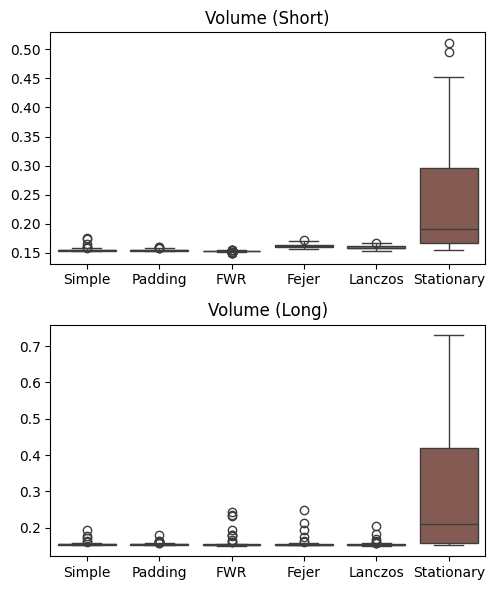

In [39]:
col_list = ['Open', 'High', 'Low', 'Close', 'Volume']


for col in col_list:
  perf_df = pd.DataFrame()
  data_simple = short_data[col]
  data_fwr = short_fwr_data[col]
  data_lin = short_lin_data[col]
  data_fej = short_fej_data[col]
  data_lan = short_lan_data[col]
  data_stat = short_stat_data[col]
  data_stat_smoothed = short_stat_smoothed_data[col]
  data_pad = short_pad_data[col]

  perf_df['Simple'] = data_simple
  perf_df['Padding'] = data_pad
  perf_df['FWR'] = data_fwr
  perf_df['Fejer'] = data_fej
  perf_df['Lanczos'] = data_lan
  # perf_df['Linear'] = data_lin
  perf_df['Stationary'] = data_stat
  # perf_df['Stationary (Smoothed)'] = data_stat_smoothed

  ## Long-term Prediction Performance:
  perf_long_df = pd.DataFrame()
  data_simple_long = long_data[col]
  data_fwr_long = long_fwr_data[col]
  data_lin_long = long_lin_data[col]
  data_fej_long = long_fej_data[col]
  data_lan_long = long_lan_data[col]
  data_stat_long = long_stat_data[col]
  data_pad_long = long_pad_data[col]

  perf_long_df['Simple'] = data_simple_long
  perf_long_df['Padding'] = data_pad_long
  perf_long_df['FWR'] = data_fwr_long
  perf_long_df['Fejer'] = data_fej_long
  perf_long_df['Lanczos'] = data_lan_long
  # perf_long_df['Linear'] = data_lin_long
  perf_long_df['Stationary'] = data_stat_long


  print('')
  print('-'*25, col, '-'*25)
  # print(perf_df.median())

  for method in method_list:
    print(f'{method} & {round(perf_df[method].median(),4)} & {round(perf_long_df[method].median(),4)} \\\\')
  print('')
  print('Smallest median NRMSE (Short):', perf_df[['Padding', 'FWR', 'Fejer', 'Lanczos', 'Stationary']].median().idxmin())
  print('Smallest median NRMSE (Long):', perf_long_df[['Padding', 'FWR', 'Fejer', 'Lanczos', 'Stationary']].median().idxmin())

  fig, axes = plt.subplots(2, 1, figsize=(5, 6), sharex = False)
  axes[0].set_title(f'{col} (Short)')
  sns.boxplot(perf_df, ax = axes[0])

  axes[1].set_title(f'{col} (Long)')
  sns.boxplot(perf_long_df, ax = axes[1])
  plt.tight_layout()
  plt.show()